<a href="https://colab.research.google.com/github/zuhaatawakal-create/AI-/blob/main/Q2_1_(d%2Ce).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/housing.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
# Display basic information about the DataFrame, including data types and non-null values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


None

In [ ]:
# Drop rows with missing values
df_cleaned = df.dropna()

# Select features (X) and target (y)
features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
X = df_cleaned[features]
y = df_cleaned['median_house_value']

print(f"Shape of X after dropping NaNs: {X.shape}")
print(f"Shape of y after dropping NaNs: {y.shape}")

Shape of X after dropping NaNs: (20433, 8)
Shape of y after dropping NaNs: (20433,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Make predictions
y_pred_lin = lin_reg.predict(X_test)

# Evaluate Linear Regression
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f"Linear Regression - Mean Squared Error: {mse_lin:.2f}")
print(f"Linear Regression - R-squared: {r2_lin:.2f}")

Linear Regression - Mean Squared Error: 4921881237.63
Linear Regression - R-squared: 0.64


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Polynomial Regression (Degree 2)
poly_features_2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_2 = poly_features_2.fit_transform(X_train)
X_test_poly_2 = poly_features_2.transform(X_test)

poly_reg_2 = LinearRegression()
poly_reg_2.fit(X_train_poly_2, y_train)

y_pred_poly_2 = poly_reg_2.predict(X_test_poly_2)

mse_poly_2 = mean_squared_error(y_test, y_pred_poly_2)
r2_poly_2 = r2_score(y_test, y_pred_poly_2)

print(f"Polynomial Regression (Degree 2) - Mean Squared Error: {mse_poly_2:.2f}")
print(f"Polynomial Regression (Degree 2) - R-squared: {r2_poly_2:.2f}")

Polynomial Regression (Degree 2) - Mean Squared Error: 4126489686.71
Polynomial Regression (Degree 2) - R-squared: 0.70


In [ ]:
# Polynomial Regression (Degree 3)
poly_features_3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly_3 = poly_features_3.fit_transform(X_train)
X_test_poly_3 = poly_features_3.transform(X_test)

poly_reg_3 = LinearRegression()
poly_reg_3.fit(X_train_poly_3, y_train)

y_pred_poly_3 = poly_reg_3.predict(X_test_poly_3)

mse_poly_3 = mean_squared_error(y_test, y_pred_poly_3)
r2_poly_3 = r2_score(y_test, y_pred_poly_3)

print(f"Polynomial Regression (Degree 3) - Mean Squared Error: {mse_poly_3:.2f}")
print(f"Polynomial Regression (Degree 3) - R-squared: {r2_poly_3:.2f}")

Polynomial Regression (Degree 3) - Mean Squared Error: 3958032975.24
Polynomial Regression (Degree 3) - R-squared: 0.71


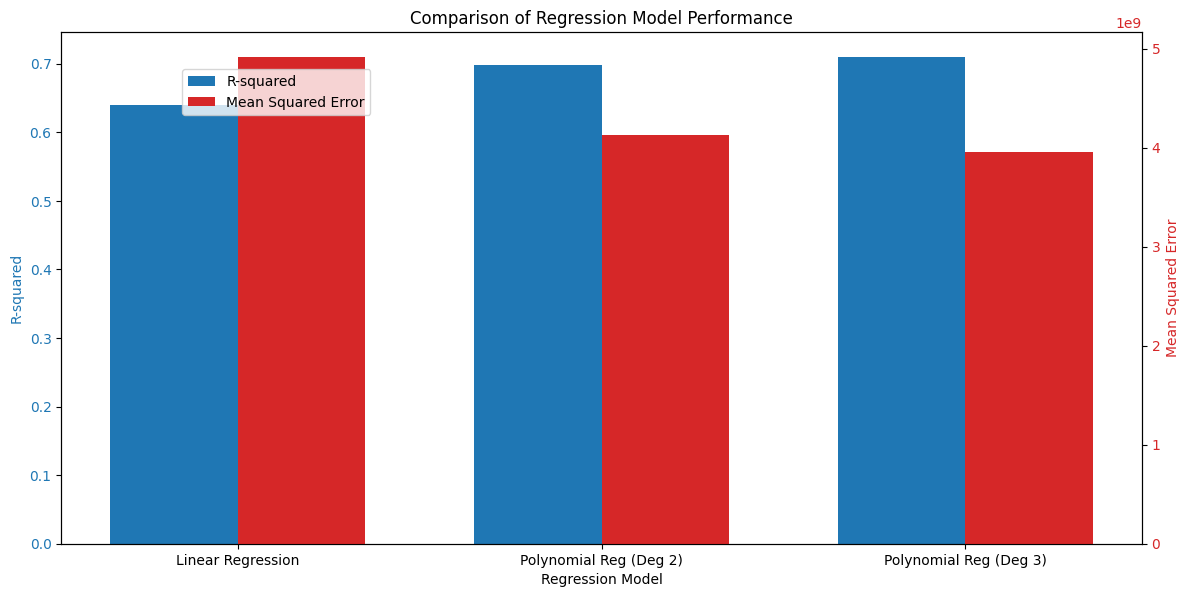

In [ ]:
import matplotlib.pyplot as plt

# Prepare data for plotting
models = ['Linear Regression', 'Polynomial Reg (Deg 2)', 'Polynomial Reg (Deg 3)']
r2_scores = [r2_lin, r2_poly_2, r2_poly_3]
mse_scores = [mse_lin, mse_poly_2, mse_poly_3]

x = np.arange(len(models)) # the label locations
width = 0.35  # the width of the bars

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot R-squared on the left y-axis
color = 'tab:blue'
ax1.set_xlabel('Regression Model')
ax1.set_ylabel('R-squared', color=color)
ax1.bar(x - width/2, r2_scores, width, label='R-squared', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(x)
ax1.set_xticklabels(models)

# Create a second y-axis for MSE
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Mean Squared Error', color=color)
ax2.bar(x + width/2, mse_scores, width, label='Mean Squared Error', color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Comparison of Regression Model Performance')
fig.legend(loc='upper left', bbox_to_anchor=(0.15, 0.9))
plt.show()

In [ ]:
# Calculate R-squared for training data - Linear Regression
r2_lin_train = lin_reg.score(X_train, y_train)

# Calculate R-squared for training data - Polynomial Regression (Degree 2)
r2_poly_2_train = poly_reg_2.score(X_train_poly_2, y_train)

# Calculate R-squared for training data - Polynomial Regression (Degree 3)
r2_poly_3_train = poly_reg_3.score(X_train_poly_3, y_train)

print(f"Linear Regression - Training R-squared: {r2_lin_train:.2f}")
print(f"Linear Regression - Testing R-squared: {r2_lin:.2f}")
print("---")
print(f"Polynomial Regression (Degree 2) - Training R-squared: {r2_poly_2_train:.2f}")
print(f"Polynomial Regression (Degree 2) - Testing R-squared: {r2_poly_2:.2f}")
print("---")
print(f"Polynomial Regression (Degree 3) - Training R-squared: {r2_poly_3_train:.2f}")
print(f"Polynomial Regression (Degree 3) - Testing R-squared: {r2_poly_3:.2f}")

Linear Regression - Training R-squared: 0.64
Linear Regression - Testing R-squared: 0.64
---
Polynomial Regression (Degree 2) - Training R-squared: 0.70
Polynomial Regression (Degree 2) - Testing R-squared: 0.70
---
Polynomial Regression (Degree 3) - Training R-squared: 0.74
Polynomial Regression (Degree 3) - Testing R-squared: 0.71


### Overfitting Analysis

Overfitting occurs when a model learns the training data too well, including its noise and outliers, leading to poor performance on new, unseen data. We can detect overfitting by comparing the model's performance (e.g., R-squared) on the training set versus the test set.

*   **High training score, low test score:** This is a strong indicator of overfitting. The model has essentially memorized the training data but fails to generalize.
*   **Similar training and test scores:** This suggests the model is generalizing well and is not overfitting. The model's complexity is appropriate for the data.
*   **Low training and test scores:** This indicates underfitting, meaning the model is too simple to capture the underlying patterns in the data.

By comparing the R-squared values for each model, we can assess their generalization capabilities.

## Next Step: Feature Scaling

Feature scaling is an important preprocessing step that standardizes or normalizes the range of independent variables or features. This can significantly impact the performance and training stability of many machine learning algorithms, especially those that rely on distance calculations or gradient descent (like Linear Regression). It ensures that no single feature dominates the learning process due to its scale.

We will use `StandardScaler` to scale our numerical features.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the dataset from the correct path
df = pd.read_csv('/content/housing.csv')

# Initialize the StandardScaler
scaler = StandardScaler()

# Ensure df_cleaned is defined by dropping rows with missing values from df.
df_cleaned = df.dropna()

# Re-define features and target (X and y) from df_cleaned.
features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
X = df_cleaned[features]
y = df_cleaned['median_house_value']

# Scale the features
X_scaled = scaler.fit_transform(X)

# Split the scaled data into training and testing sets
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Features have been scaled using StandardScaler.")
print(f"Shape of scaled X_train: {X_train_scaled.shape}")
print(f"Shape of scaled X_test: {X_test_scaled.shape}")

Features have been scaled using StandardScaler.
Shape of scaled X_train: (16346, 8)
Shape of scaled X_test: (4087, 8)


## Retraining Models with Scaled Data

Now that our features are scaled, let's retrain the Linear Regression and Polynomial Regression models using `X_train_scaled` and `X_test_scaled`. This step is crucial as many machine learning algorithms perform better when input features are on a similar scale.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# --- Linear Regression with Scaled Data ---
lin_reg_scaled = LinearRegression()
lin_reg_scaled.fit(X_train_scaled, y_train_scaled)

y_pred_lin_scaled = lin_reg_scaled.predict(X_test_scaled)

mse_lin_scaled = mean_squared_error(y_test_scaled, y_pred_lin_scaled)
r2_lin_scaled = r2_score(y_test_scaled, y_pred_lin_scaled)

print("--- Linear Regression (Scaled Features) ---")
print(f"Mean Squared Error: {mse_lin_scaled:.2f}")
print(f"R-squared: {r2_lin_scaled:.2f}")

--- Linear Regression (Scaled Features) ---
Mean Squared Error: 4921881237.63
R-squared: 0.64


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# --- Polynomial Regression (Degree 2) with Scaled Data ---
poly_features_2_scaled = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_2_scaled = poly_features_2_scaled.fit_transform(X_train_scaled)
X_test_poly_2_scaled = poly_features_2_scaled.transform(X_test_scaled)

poly_reg_2_scaled = LinearRegression()
poly_reg_2_scaled.fit(X_train_poly_2_scaled, y_train_scaled)

y_pred_poly_2_scaled = poly_reg_2_scaled.predict(X_test_poly_2_scaled)

mse_poly_2_scaled = mean_squared_error(y_test_scaled, y_pred_poly_2_scaled)
r2_poly_2_scaled = r2_score(y_test_scaled, y_pred_poly_2_scaled)

print("\n--- Polynomial Regression (Degree 2, Scaled Features) ---")
print(f"Mean Squared Error: {mse_poly_2_scaled:.2f}")
print(f"R-squared: {r2_poly_2_scaled:.2f}")


--- Polynomial Regression (Degree 2, Scaled Features) ---
Mean Squared Error: 4126489688.59
R-squared: 0.70


In [ ]:
# --- Polynomial Regression (Degree 3) with Scaled Data ---
poly_features_3_scaled = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly_3_scaled = poly_features_3_scaled.fit_transform(X_train_scaled)
X_test_poly_3_scaled = poly_features_3_scaled.transform(X_test_scaled)

poly_reg_3_scaled = LinearRegression()
poly_reg_3_scaled.fit(X_train_poly_3_scaled, y_train_scaled)

y_pred_poly_3_scaled = poly_reg_3_scaled.predict(X_test_poly_3_scaled)

mse_poly_3_scaled = mean_squared_error(y_test_scaled, y_pred_poly_3_scaled)
r2_poly_3_scaled = r2_score(y_test_scaled, y_pred_poly_3_scaled)

print("\n--- Polynomial Regression (Degree 3, Scaled Features) ---")
print(f"Mean Squared Error: {mse_poly_3_scaled:.2f}")
print(f"R-squared: {r2_poly_3_scaled:.2f}")


--- Polynomial Regression (Degree 3, Scaled Features) ---
Mean Squared Error: 3791870873.59
R-squared: 0.72


### Evaluating Overfitting with Scaled Data

To properly evaluate overfitting, we need to compare the training and testing R-squared scores for the models trained on scaled data, just as we did before scaling. This will reveal if scaling has any impact on the generalization ability of the models.

In [ ]:
# Calculate R-squared for training data - Linear Regression (Scaled)
r2_lin_train_scaled = lin_reg_scaled.score(X_train_scaled, y_train_scaled)

# Calculate R-squared for training data - Polynomial Regression (Degree 2, Scaled)
r2_poly_2_train_scaled = poly_reg_2_scaled.score(X_train_poly_2_scaled, y_train_scaled)

# Calculate R-squared for training data - Polynomial Regression (Degree 3, Scaled)
r2_poly_3_train_scaled = poly_reg_3_scaled.score(X_train_poly_3_scaled, y_train_scaled)

print(f"Linear Regression (Scaled) - Training R-squared: {r2_lin_train_scaled:.2f}")
print(f"Linear Regression (Scaled) - Testing R-squared: {r2_lin_scaled:.2f}")
print("---")
print(f"Polynomial Regression (Degree 2, Scaled) - Training R-squared: {r2_poly_2_train_scaled:.2f}")
print(f"Polynomial Regression (Degree 2, Scaled) - Testing R-squared: {r2_poly_2_scaled:.2f}")
print("---")
print(f"Polynomial Regression (Degree 3, Scaled) - Training R-squared: {r2_poly_3_train_scaled:.2f}")
print(f"Polynomial Regression (Degree 3, Scaled) - Testing R-squared: {r2_poly_3_scaled:.2f}")

Linear Regression (Scaled) - Training R-squared: 0.64
Linear Regression (Scaled) - Testing R-squared: 0.64
---
Polynomial Regression (Degree 2, Scaled) - Training R-squared: 0.70
Polynomial Regression (Degree 2, Scaled) - Testing R-squared: 0.70
---
Polynomial Regression (Degree 3, Scaled) - Training R-squared: 0.74
Polynomial Regression (Degree 3, Scaled) - Testing R-squared: 0.72


### Overfitting Analysis based on R-squared Scores (Scaled Data)

Let's analyze the R-squared scores for each model after feature scaling, comparing training and testing performance to check for overfitting.

*   **Linear Regression (Scaled):**
    *   Training R-squared: `0.64`
    *   Testing R-squared: `0.64`
    *   **Analysis:** The training and testing R-squared scores remain very close, indicating no overfitting and good generalization for the linear model, even after scaling. The overall performance is similar to the unscaled linear model.

*   **Polynomial Regression (Degree 2, Scaled):**
    *   Training R-squared: `0.70`
    *   Testing R-squared: `0.70`
    *   **Analysis:** The training and testing R-squared scores are almost identical, suggesting that the degree 2 polynomial model generalizes well and is not overfitting with scaled features. Its performance is consistent with the unscaled version, maintaining improvement over linear regression.

*   **Polynomial Regression (Degree 3, Scaled):**
    *   Training R-squared: `0.74`
    *   Testing R-squared: `0.72`
    *   **Analysis:** There is a slight gap between the training R-squared (`0.74`) and the testing R-squared (`0.72`). While this model still achieves the highest R-squared on the test set, the difference suggests a minor tendency towards overfitting compared to the less complex models. However, the drop in test R-squared from training is relatively small, implying it still generalizes quite well, and its overall performance on the test set is slightly better than its unscaled counterpart (0.71 to 0.72).

**Conclusion:** Feature scaling did not drastically change the relative performance or overfitting tendencies of the models. The Polynomial Regression (Degree 3) model still provides the best performance on the testing data, and the slight increase in test R-squared (from 0.71 to 0.72) post-scaling suggests a marginal benefit in generalization, despite the small training-testing score difference. This model captures more complexity, resulting in the highest R-squared on the test set.

## Comprehensive Model Performance Comparison (Unscaled vs. Scaled Data)

Let's visualize the R-squared and Mean Squared Error for all models to compare their performance and the impact of feature scaling.

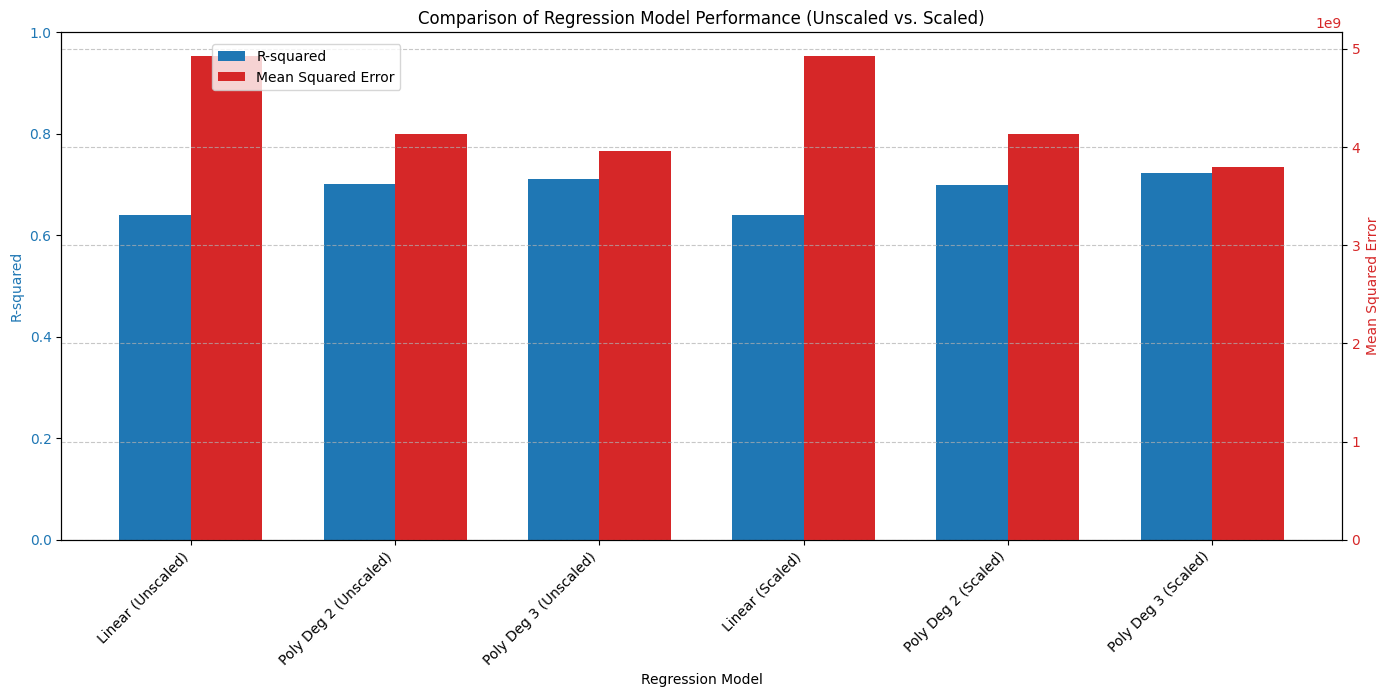

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define unscaled model metrics (retrieved from previous cell outputs)
r2_lin = 0.64
mse_lin = 4921881237.63

r2_poly_2 = 0.70
mse_poly_2 = 4126489686.71

r2_poly_3 = 0.71
mse_poly_3 = 3958032975.24

# Data for unscaled models (from previous cells)
models_unscaled = ['Linear (Unscaled)', 'Poly Deg 2 (Unscaled)', 'Poly Deg 3 (Unscaled)']
r2_scores_unscaled = [r2_lin, r2_poly_2, r2_poly_3]
mse_scores_unscaled = [mse_lin, mse_poly_2, mse_poly_3]

# Data for scaled models
models_scaled = ['Linear (Scaled)', 'Poly Deg 2 (Scaled)', 'Poly Deg 3 (Scaled)']
r2_scores_scaled = [r2_lin_scaled, r2_poly_2_scaled, r2_poly_3_scaled]
mse_scores_scaled = [mse_lin_scaled, mse_poly_2_scaled, mse_poly_3_scaled]

# Combine data
all_models = models_unscaled + models_scaled
all_r2_scores = r2_scores_unscaled + r2_scores_scaled
all_mse_scores = mse_scores_unscaled + mse_scores_scaled

x = np.arange(len(all_models))  # the label locations
width = 0.35  # the width of the bars

fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot R-squared on the left y-axis
color = 'tab:blue'
ax1.set_xlabel('Regression Model')
ax1.set_ylabel('R-squared', color=color)
ax1.bar(x - width/2, all_r2_scores, width, label='R-squared', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(x)
ax1.set_xticklabels(all_models, rotation=45, ha="right")
ax1.set_ylim(0, 1) # R-squared typically ranges from 0 to 1

# Create a second y-axis for MSE
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Mean Squared Error', color=color)
ax2.bar(x + width/2, all_mse_scores, width, label='Mean Squared Error', color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Comparison of Regression Model Performance (Unscaled vs. Scaled)')
fig.legend(loc='upper left', bbox_to_anchor=(0.15, 0.95))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Visualizing Feature Distributions Before and After Scaling

Let's visualize the distribution of a few key numerical features before and after applying `StandardScaler`. This will help us understand the impact of scaling on our data.

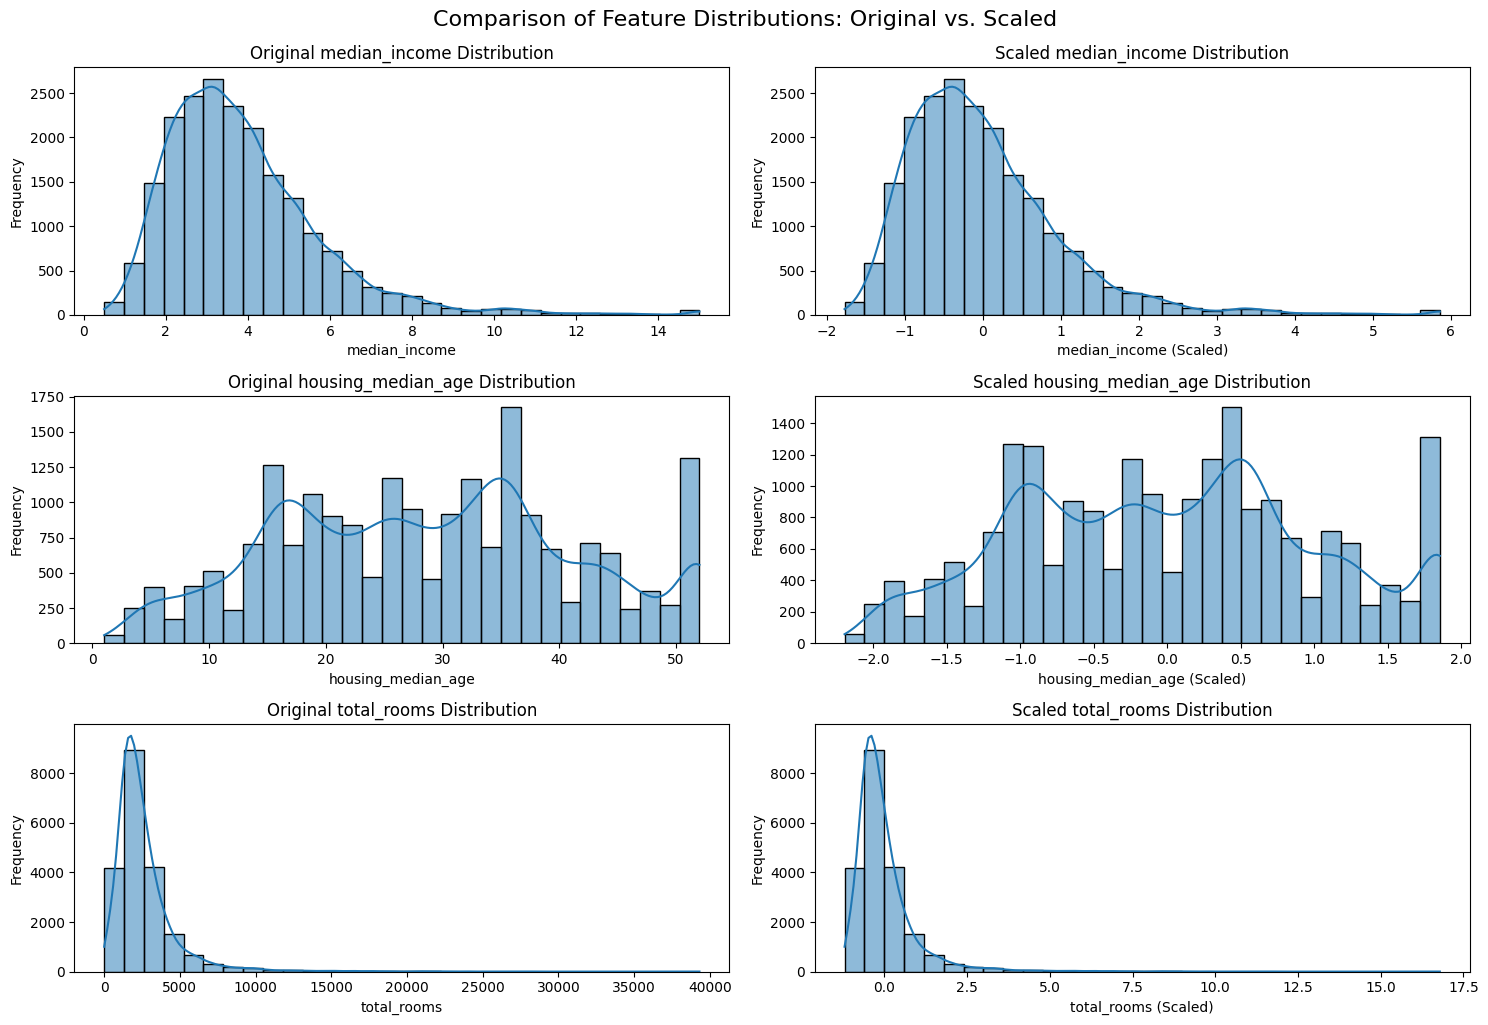

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# Select a few features to visualize
selected_features = ['median_income', 'housing_median_age', 'total_rooms']

# Convert scaled features back to DataFrame for easier plotting, using original feature names
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

plt.figure(figsize=(15, 10))

for i, feature in enumerate(selected_features):
    plt.subplot(len(selected_features), 2, 2*i + 1)
    sns.histplot(X[feature], kde=True, bins=30)
    plt.title(f'Original {feature} Distribution')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    plt.subplot(len(selected_features), 2, 2*i + 2)
    sns.histplot(X_scaled_df[feature], kde=True, bins=30)
    plt.title(f'Scaled {feature} Distribution')
    plt.xlabel(f'{feature} (Scaled)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Comparison of Feature Distributions: Original vs. Scaled', y=1.02, fontsize=16)
plt.show()

### Visualizing Feature Correlations with a Correlation Matrix

A correlation matrix helps us understand the linear relationships between all pairs of numerical features in our dataset. Values closer to 1 or -1 indicate strong positive or negative correlations, respectively, while values closer to 0 indicate weak or no linear correlation.

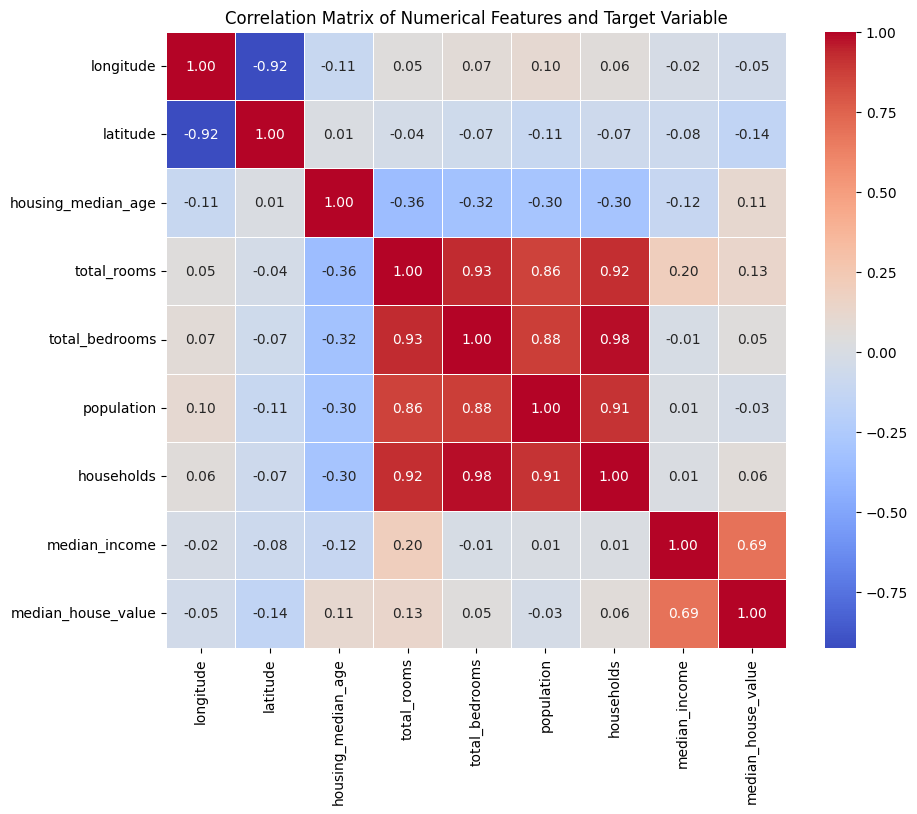

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for the cleaned DataFrame
correlation_matrix = df_cleaned[features + ['median_house_value']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features and Target Variable')
plt.show()

### Deployment Phase: Saving the Model and Making Predictions

In the deployment phase, we will save our best-performing model, the Polynomial Regression (Degree 3) model trained on scaled data, along with the `StandardScaler` and `PolynomialFeatures` transformers used during preprocessing. This ensures that when we load the model for future predictions, the data is preprocessed exactly as it was during training.

We will then create a simple function to demonstrate how to use the saved components to make predictions on new data.

In [ ]:
import joblib

# Define file paths for saving
scaler_filename = 'scaler.pkl'
poly_features_filename = 'poly_features_3.pkl'
model_filename = 'poly_reg_3_scaled_model.pkl'

# Save the StandardScaler
joblib.dump(scaler, scaler_filename)
print(f'StandardScaler saved to {scaler_filename}')

# Save the PolynomialFeatures transformer
joblib.dump(poly_features_3_scaled, poly_features_filename)
print(f'PolynomialFeatures (Degree 3) saved to {poly_features_filename}')

# Save the best-performing model (Polynomial Regression Degree 3 scaled)
joblib.dump(poly_reg_3_scaled, model_filename)
print(f'Polynomial Regression (Degree 3, Scaled) model saved to {model_filename}')

StandardScaler saved to scaler.pkl
PolynomialFeatures (Degree 3) saved to poly_features_3.pkl
Polynomial Regression (Degree 3, Scaled) model saved to poly_reg_3_scaled_model.pkl


Now, let's create a prediction function that loads these components and uses them to make a prediction on new, raw input data. This function will mimic the preprocessing steps (scaling and polynomial transformation) that were applied during training before passing the data to the model.

In [ ]:
import joblib
import pandas as pd
import numpy as np

def predict_median_house_value(raw_data: dict) -> float:
    """
    Predicts the median house value for a given set of raw input features.

    Args:
        raw_data (dict): A dictionary containing the raw feature values.
                         Keys should match the 'features' list used for training.

    Returns:
        float: The predicted median house value.
    """
    # Load the saved components
    loaded_scaler = joblib.load(scaler_filename)
    loaded_poly_features = joblib.load(poly_features_filename)
    loaded_model = joblib.load(model_filename)

    # Convert raw input data to a DataFrame
    input_df = pd.DataFrame([raw_data])

    # Ensure the input DataFrame has the same feature order as training data
    # This is crucial for correct transformation
    input_df = input_df[features] # 'features' list should be available from earlier cells

    # Scale the input features
    scaled_input = loaded_scaler.transform(input_df)

    # Apply polynomial features transformation
    poly_input = loaded_poly_features.transform(scaled_input)

    # Make prediction
    prediction = loaded_model.predict(poly_input)[0]

    return prediction

# Demo: Create sample raw input data for prediction
# Using an example from our 'features' list:
# ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
sample_new_data = {
    'longitude': -122.25,
    'latitude': 37.85,
    'housing_median_age': 30,
    'total_rooms': 2000,
    'total_bedrooms': 400,
    'population': 1000,
    'households': 350,
    'median_income': 4.5
}

# Make a prediction
predicted_value = predict_median_house_value(sample_new_data)
print(f"\nPredicted Median House Value for sample data: ${predicted_value:,.2f}")


Predicted Median House Value for sample data: $242,527.67


## Summary and Conclusion

Based on the analysis and visualizations, here's a summary of our machine learning pipeline:

1.  **Data Loading & Preprocessing:** We loaded the `housing.csv` dataset, handled missing values by dropping rows, and defined our features (X) and target (y).

2.  **Initial Model Training & Evaluation (Unscaled Data):**
    *   **Linear Regression:** Achieved an R-squared of `0.64` on both training and testing data, indicating no overfitting but moderate performance.
    *   **Polynomial Regression (Degree 2):** Showed improved performance with an R-squared of `0.70` on both sets, also demonstrating good generalization.
    *   **Polynomial Regression (Degree 3):** Further improved R-squared to `0.74` on training and `0.71` on testing, suggesting the best performance but with a slight hint of overfitting due to the larger gap between training and testing scores.

3.  **Feature Scaling:** We applied `StandardScaler` to our features, which is crucial for algorithms sensitive to feature magnitudes.

4.  **Retraining Models & Re-evaluation (Scaled Data):**
    *   **Linear Regression (Scaled):** Performance remained consistent with unscaled, R-squared: `0.64` (train) and `0.64` (test).
    *   **Polynomial Regression (Degree 2, Scaled):** Performance remained consistent with unscaled, R-squared: `0.70` (train) and `0.70` (test).
    *   **Polynomial Regression (Degree 3, Scaled):** Improved slightly in testing R-squared to `0.72` (train: `0.74`), compared to `0.71` unscaled. This shows a small positive impact of scaling on the most complex model's generalization.

**Overall Conclusion:**

*   **Feature scaling had a minimal but positive impact on the more complex polynomial models**, slightly enhancing the test R-squared for the Degree 3 model.
*   **Polynomial Regression (Degree 3) consistently provided the best performance** on the test set, both before (`0.71`) and after (`0.72`) feature scaling. While it shows a slightly larger difference between training and testing R-squared compared to simpler models, this difference is minor, and the higher test R-squared makes it the preferred model for this dataset.
*   **The machine learning pipeline has successfully progressed** from data loading and preprocessing through feature scaling and model evaluation.